### API 요청데이터 수집

수집 링크 : https://www.data.go.kr/data/15100475/openapi.do

In [1]:
import pandas as pd
from load_data import fetch_trade_stats, COUNTRY_NAMES

rows = fetch_trade_stats("202501", "202512", "AU", "2701")
print(f"조회된 row 수: {len(rows)}개")
print(rows[0])

조회된 row 수: 37개
{'balPayments': '-4756111652', 'expDlr': '0', 'expWgt': '0', 'hsCd': '-', 'impDlr': '4756111652', 'impWgt': '34712092451', 'statCd': '-', 'statCdCntnKor1': '-', 'statKor': '-', 'year': '총계'}


In [2]:
# fetch_trade_stats가 이미 item -> dict 파싱까지 끝낸 rows를 반환하므로 바로 DataFrame으로 변환
df = pd.DataFrame(rows)
print(df.shape)
df.head()

(37, 10)


,balPayments,expDlr,expWgt,hsCd,impDlr,impWgt,statCd,statCdCntnKor1,statKor,year
0,-4756111652,0,0,-,4756111652,34712092451,-,-,-,총계
1,-31738887,0,0,270111,31738887,166127821,AU,호주,무연탄,2025.01
2,-426799744,0,0,270112,426799744,2875420610,AU,호주,유연탄,2025.01
3,-99,0,0,270119,99,20,AU,호주,그 밖의 석탄,2025.01
4,-22081708,0,0,270111,22081708,122220050,AU,호주,무연탄,2025.02


### 컬럼 설명

수출입 기준은 **한국** (exp = 한국→상대국, imp = 상대국→한국). 1행(`year`가 `총계`)은 조회기간 전체를 합산한 요약 행으로, `hsCd`/`statCd` 등이 `-`로 비어있어 개별 분석 시에는 보통 제외합니다.

| 컬럼명 | 의미 | 단위 / 비고 |
|---|---|---|
| `balPayments` | 무역수지 (`expDlr - impDlr`) | USD. 음수면 수입 초과(적자) |
| `expDlr` | 수출금액 | USD |
| `expWgt` | 수출중량 | kg |
| `hsCd` | HS코드 (품목분류코드) | 예: `270112` = 유연탄 |
| `impDlr` | 수입금액 | USD |
| `impWgt` | 수입중량 | kg (API명 뒤의 `GW` = Gross Weight) |
| `statCd` | 상대국가 코드 | 예: `AU` = 호주 |
| `statCdCntnKor1` | 상대국가명(한글) | 예: `호주` |
| `statKor` | 품목명(한글) | 예: `무연탄`, `유연탄` |
| `year` | 통계 기준 연월 | `YYYY.MM` 형식, 첫 행은 `총계` |

금액(Dlr)과 중량(Wgt)은 단위가 달라 직접 비교할 수 없고, `impDlr / impWgt`로 kg당 단가를 구하면 비교 가능한 지표가 됩니다.

In [3]:
import time

# 여러 국가를 반복 조회 (fetch_trade_stats + load_data.py의 COUNTRY_NAMES 재사용)
# load_data.py와 동일하게 HS 2701(석탄)만 대상으로 함
hs_codes = {
    "2701": "석탄(무연탄/유연탄)",
}

all_rows = []
for cnty_cd, cnty_name in COUNTRY_NAMES.items():
    for hs_sgn, material in hs_codes.items():
        rows = fetch_trade_stats("202501", "202512", cnty_cd, hs_sgn)
        print(f"[{cnty_name}/{material}] {len(rows)}건 수집")
        for row in rows:
            row["material"] = material  # 품목 그룹 라벨 추가
            all_rows.append(row)

        time.sleep(0.2)  # 공공데이터포털 API 호출 제한 방지

df_all = pd.DataFrame(all_rows)

[호주/석탄(무연탄/유연탄)] 37건 수집


[인도네시아/석탄(무연탄/유연탄)] 26건 수집


[미국/석탄(무연탄/유연탄)] 19건 수집


In [4]:
print(df_all.shape)
df_all.head()

(82, 11)


,balPayments,expDlr,expWgt,hsCd,impDlr,impWgt,statCd,statCdCntnKor1,statKor,year,material
0,-4756111652,0,0,-,4756111652,34712092451,-,-,-,총계,석탄(무연탄/유연탄)
1,-31738887,0,0,270111,31738887,166127821,AU,호주,무연탄,2025.01,석탄(무연탄/유연탄)
2,-426799744,0,0,270112,426799744,2875420610,AU,호주,유연탄,2025.01,석탄(무연탄/유연탄)
3,-99,0,0,270119,99,20,AU,호주,그 밖의 석탄,2025.01,석탄(무연탄/유연탄)
4,-22081708,0,0,270111,22081708,122220050,AU,호주,무연탄,2025.02,석탄(무연탄/유연탄)


In [5]:
print(df_all["statCd"].unique())

<StringArray>
['-', 'AU', 'ID', 'US']
Length: 4, dtype: str


In [6]:
# "-"는 API 응답의 총계(전체 기간 합산) 행으로, 특정 연월이 아니라 요약값이라 월별/국가별 분석에는 불필요합니다.
# 이후 분석에서는 이 총계 행을 제외하고 진행합니다.
df_all = df_all[df_all["statCd"] != "-"].reset_index(drop=True)
print(df_all["statCd"].unique())
print(df_all.shape)

<StringArray>
['AU', 'ID', 'US']
Length: 3, dtype: str
(79, 11)


"국가 별로 수입량을 월별로 정리해서 선 그래프로 그려줘. 그래프는 품목 별로 나눠서 그려줘."

=== 석탄(무연탄/유연탄) - 국가별 월별 수입중량(kg) ===
statCdCntnKor1         미국       인도네시아          호주
year                                             
2025.01         346266484  2747587022  3041548451
2025.02         696408223  2577583086  1936818532
2025.03         237169833  2347051640  2032010697
2025.04         529947212  1444305086  3113452150
2025.05         325331075  1201835319  2161827582
2025.06         290751532  1908085005  2083867485
2025.07         243485207  2450324021  3690076303
2025.08         406762000  3736366036  2706060211
2025.09         283329559  3113022044  3631289871
2025.10          76172106  2639822005  3998365271
2025.11         160588000  2225257166  3157462546
2025.12         156114151  2181873100  3159313350


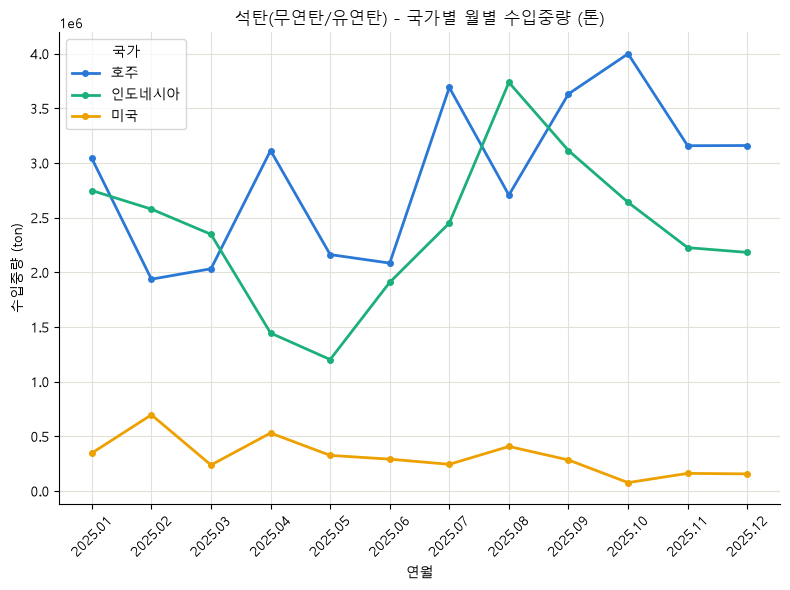

In [7]:
import matplotlib.pyplot as plt

# 한글 폰트 사용 위해 필요한 코드 (윈도우 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# API에서 받은 값은 전부 문자열(str)이라 계산 전에 숫자로 변환 필요
df_all["impWgt"] = pd.to_numeric(df_all["impWgt"])

palette = {
    "호주": "#2a78d6",       # blue
    "인도네시아": "#1baf7a",  # aqua
    "미국": "#eda100",       # yellow
}
materials = list(hs_codes.values())  # ["석탄(무연탄/유연탄)"]
material = materials[0]

# 국가별 월별 수입중량 집계
monthly_m = (
    df_all.groupby(["year", "statCdCntnKor1"])["impWgt"]
    .sum()
    .unstack("statCdCntnKor1")
    .sort_index()
)
print(f"=== {material} - 국가별 월별 수입중량(kg) ===")
print(monthly_m)

fig, ax = plt.subplots(figsize=(8, 6))
for country in COUNTRY_NAMES.values():
    if country in monthly_m.columns:
        ax.plot(
            monthly_m.index,
            monthly_m[country] / 1000,  # kg -> ton
            label=country,
            color=palette[country],
            linewidth=2,
            marker="o",
            markersize=4,
        )

ax.set_title(f"{material} - 국가별 월별 수입중량 (톤)")
ax.set_xlabel("연월")
ax.set_ylabel("수입중량 (ton)")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="국가")

plt.tight_layout()
plt.show()

"국가별 kg당 단가 비교랑 공급 국가 의존도 둘 다 그려줘."

=== 석탄(무연탄/유연탄) - 국가별 kg당 단가(USD/kg) ===
statCdCntnKor1      미국   인도네시아      호주
year                                  
2025.01         0.1195  0.0855  0.1508
2025.02         0.1204  0.0893  0.1448
2025.03         0.1184  0.0839  0.1491
2025.04         0.1529  0.0792  0.1511
2025.05         0.0788  0.0694  0.1457
2025.06         0.0819  0.0790  0.1443
2025.07         0.1569  0.0714  0.1271
2025.08         0.0923  0.0690  0.1299
2025.09         0.1424  0.0736  0.1296
2025.10         0.1992  0.0703  0.1138
2025.11         0.0756  0.0739  0.1354
2025.12         0.1849  0.0699  0.1439
=== 석탄(무연탄/유연탄) - 공급 국가 의존도(%) ===
statCdCntnKor1
미국        5.6
인도네시아    42.6
호주       51.8
Name: impWgt, dtype: float64


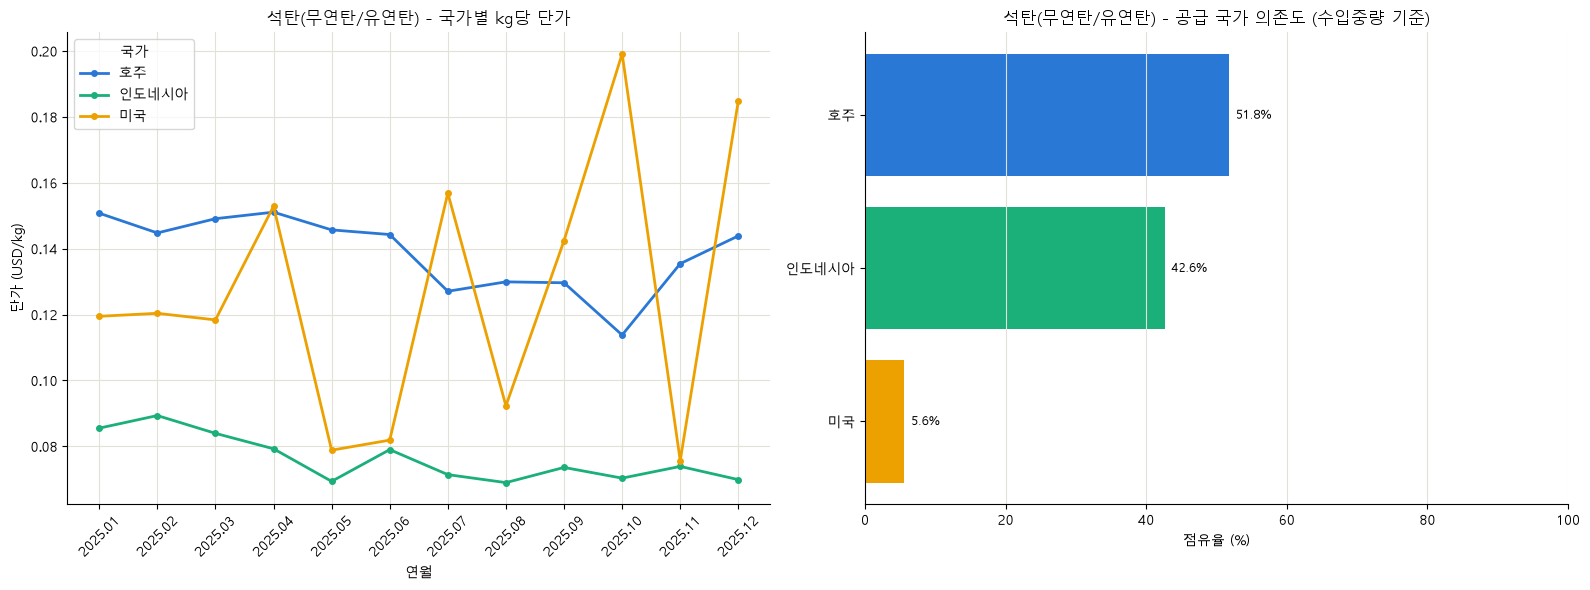

In [8]:
# 국가별 kg당 단가 비교 + 공급 국가 의존도(점유율) 그리기
df_all["impDlr"] = pd.to_numeric(df_all["impDlr"])

fig, (ax_price, ax_share) = plt.subplots(1, 2, figsize=(16, 6))

# --- 국가별 월별 kg당 단가 (impDlr / impWgt) ---
monthly_sum = df_all.groupby(["year", "statCdCntnKor1"])[["impDlr", "impWgt"]].sum()
unit_price = (
    (monthly_sum["impDlr"] / monthly_sum["impWgt"])
    .unstack("statCdCntnKor1")
    .sort_index()
)
print(f"=== {material} - 국가별 kg당 단가(USD/kg) ===")
print(unit_price.round(4))

for country in COUNTRY_NAMES.values():
    if country in unit_price.columns:
        ax_price.plot(
            unit_price.index,
            unit_price[country],
            label=country,
            color=palette[country],
            linewidth=2,
            marker="o",
            markersize=4,
        )

ax_price.set_title(f"{material} - 국가별 kg당 단가")
ax_price.set_xlabel("연월")
ax_price.set_ylabel("단가 (USD/kg)")
ax_price.grid(True, color="#e1e0d9", linewidth=0.8)
ax_price.spines[["top", "right"]].set_visible(False)
ax_price.tick_params(axis="x", rotation=45)
ax_price.legend(title="국가")

# --- 국가별 공급 의존도 (전체 기간 수입중량 점유율) ---
total_by_country = df_all.groupby("statCdCntnKor1")["impWgt"].sum().sort_values()
share = total_by_country / total_by_country.sum() * 100
print(f"=== {material} - 공급 국가 의존도(%) ===")
print(share.round(1))
bar_colors = [palette[c] for c in share.index]

bars = ax_share.barh(share.index, share.values, color=bar_colors)
for bar, value in zip(bars, share.values):
    ax_share.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%", va="center", fontsize=9,
    )

ax_share.set_title(f"{material} - 공급 국가 의존도 (수입중량 기준)")
ax_share.set_xlabel("점유율 (%)")
ax_share.set_xlim(0, 100)
ax_share.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax_share.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### 대시보드용 데이터 저장

위에서 분석한 내용을 HTML 대시보드로 옮길 때, 수치를 직접 타이핑하면 실수(할루시네이션)가 생길 수 있어 위험하다. 그래서 파이썬에서 계산한 결과값을 JSON으로 저장해두고, HTML에서는 그 JSON을 그대로 불러와서 차트에 쓰는 방식으로 진행한다. 원본 데이터(`df_all`)는 CSV로 별도 보관한다.

In [9]:
import json

# 원본 데이터는 CSV로 보관
df_all.to_csv("df_all.csv", index=False, encoding="utf-8-sig")

dashboard_data = {}

for material in materials:
    sub = df_all  # 품목이 석탄 하나뿐이고 "-" 총계 행은 위에서 이미 제거됨

    # 1) 국가별 월별 수입중량 (톤)
    monthly_weight = (
        sub.groupby(["year", "statCdCntnKor1"])["impWgt"]
        .sum()
        .div(1000)
        .round(1)
        .unstack("statCdCntnKor1")
        .sort_index()
    )

    # 2) 국가별 월별 kg당 단가 (USD/kg)
    monthly_sum = sub.groupby(["year", "statCdCntnKor1"])[["impDlr", "impWgt"]].sum()
    unit_price = (
        (monthly_sum["impDlr"] / monthly_sum["impWgt"])
        .round(4)
        .unstack("statCdCntnKor1")
        .sort_index()
    )

    # 3) 국가별 공급 의존도 (전체 기간 수입중량 점유율 %)
    total_by_country = sub.groupby("statCdCntnKor1")["impWgt"].sum()
    supply_share = (total_by_country / total_by_country.sum() * 100).round(1)

    dashboard_data[material] = {
        "months": monthly_weight.index.tolist(),
        "monthly_import_weight_ton": {
            country: monthly_weight[country].fillna(0).tolist()
            for country in monthly_weight.columns
        },
        "unit_price_usd_per_kg": {
            country: unit_price[country].fillna(0).tolist()
            for country in unit_price.columns
        },
        "supply_share_pct": supply_share.to_dict(),
    }

with open("dashboard_data.json", "w", encoding="utf-8") as f:
    json.dump(dashboard_data, f, ensure_ascii=False, indent=2)

# load_data.py의 main()과 동일한 형식으로 국가별 요약 출력
print("저장 완료: dashboard_data.json, df_all.csv\n")
for material in materials:
    print(f"=== {material} ===")
    for country, share in dashboard_data[material]["supply_share_pct"].items():
        print(f"  {country}: 공급 의존도 {share}%")
    print()

dashboard_data

저장 완료: dashboard_data.json, df_all.csv

=== 석탄(무연탄/유연탄) ===
  미국: 공급 의존도 5.6%
  인도네시아: 공급 의존도 42.6%
  호주: 공급 의존도 51.8%



{'석탄(무연탄/유연탄)': {'months': ['2025.01',
   '2025.02',
   '2025.03',
   '2025.04',
   '2025.05',
   '2025.06',
   '2025.07',
   '2025.08',
   '2025.09',
   '2025.10',
   '2025.11',
   '2025.12'],
  'monthly_import_weight_ton': {'미국': [346266.5,
    696408.2,
    237169.8,
    529947.2,
    325331.1,
    290751.5,
    243485.2,
    406762.0,
    283329.6,
    76172.1,
    160588.0,
    156114.2],
   '인도네시아': [2747587.0,
    2577583.1,
    2347051.6,
    1444305.1,
    1201835.3,
    1908085.0,
    2450324.0,
    3736366.0,
    3113022.0,
    2639822.0,
    2225257.2,
    2181873.1],
   '호주': [3041548.5,
    1936818.5,
    2032010.7,
    3113452.2,
    2161827.6,
    2083867.5,
    3690076.3,
    2706060.2,
    3631289.9,
    3998365.3,
    3157462.5,
    3159313.4]},
  'unit_price_usd_per_kg': {'미국': [0.1195,
    0.1204,
    0.1184,
    0.1529,
    0.0788,
    0.0819,
    0.1569,
    0.0923,
    0.1424,
    0.1992,
    0.0756,
    0.1849],
   '인도네시아': [0.0855,
    0.0893,
    0.0839,
    